# Product Review Classifier – Video Games Dataset
## Amazon Product Review Analysis using NLP

**Objective:** Build an automated NLP pipeline to:
1. Ingest raw customer reviews **(Stratified Sampling – equal positive/negative)**
2. Preprocess text **(Fixed – all punctuation properly removed)**
3. Extract product features via POS tagging
4. Analyse syntax via Dependency Parsing **(Visual arc graph added)**
5. Classify reviews as Positive / Negative using Machine Learning

## Setup & Installation

In [1]:
# Install required packages (run once)
!pip install pandas numpy matplotlib seaborn networkx --break-system-packages
!pip install nltk spacy textblob scikit-learn --break-system-packages
!pip install wordcloud --break-system-packages
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.0 MB/s eta 0:00:12
     - -------------------------------------- 0.5/12.8 MB 1.0 MB/s eta 0:00:12
     -- ------------------------------------ 0.8/12.8 MB 937.1 kB/s eta 0:00:13
     --- ----------------------------------- 1.0/12.8 MB 834.5 kB/s eta 0:00:15
     --- ----------------------------------- 1.0/12.8 MB 834.5 kB/s eta 0:00:15
     --- ----------------------------------- 1.3/12.8 MB 864.3 kB/s eta 0:00:14
     --- ----------------------------------- 1.3/12.8 MB 864.3 kB/s eta 0:00:14
     ---- ---------------------------------- 1.6/12.8 MB 745.6 kB/s eta 0:00:16
     ----- --------------------------------- 1.8/12.8 MB 775.6 kB/s eta 0:00:15
     ----- --------------------------------- 1.8/12.8 MB 775.6 kB/

## Imports & Configuration

In [2]:
import json, os, random, pickle, warnings, re
from collections import Counter
from matplotlib.path import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

import nltk, spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

# NLTK downloads
for r in ['stopwords','wordnet','omw-1.4','punkt','punkt_tab','averaged_perceptron_tagger']:
    nltk.download(r, quiet=True)

nlp = spacy.load('en_core_web_sm')
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## Phase 1 – Data Ingestion
### 1.1 Load Dataset with Stratified Sampling

**Fix:** The original code loaded the first N lines regardless of class, giving ~80% Positive reviews
(Amazon data is heavily skewed positive). The new function fills two separate buckets
(positive / negative) each capped at `total_reviews // 2`, so the dataset is always
**perfectly balanced** while the total sample size stays the same.

In [35]:
def load_amazon_reviews_stratified(file_path: str, total_reviews: int = 10000):
    """
    Load Amazon reviews with STRATIFIED SAMPLING.

    Each class (Positive: rating>=4, Negative: rating<4) gets exactly
    total_reviews // 2 samples, guaranteeing a 50/50 balanced dataset
    while keeping the total number of reviews the same as before.
    """
    per_class = total_reviews // 2
    positives = []   # rating >= 4
    negatives = []   # rating <  4

    with open(file_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            if len(positives) >= per_class and len(negatives) >= per_class:
                break                           # both buckets full – stop early
            try:
                review = json.loads(line.strip())
                rating = float(review.get('overall', 3))
                if rating >= 4.0 and len(positives) < per_class:
                    positives.append(review)
                elif rating < 4.0 and len(negatives) < per_class:
                    negatives.append(review)
            except (json.JSONDecodeError, ValueError):
                continue

    combined = positives + negatives
    random.seed(42)
    random.shuffle(combined)          # interleave classes

    df = pd.DataFrame(combined)
    print(f"✓ Stratified sampling done!")
    print(f"  Total      : {len(df)}")
    print(f"  Positive   : {len(positives)}  (rating ≥ 4)")
    print(f"  Negative   : {len(negatives)}  (rating < 4)")
    return df

print("✓ load_amazon_reviews_stratified() defined")

✓ load_amazon_reviews_stratified() defined


### 1.2 Load the Dataset

In [36]:
file_path = r"C:\Users\Sahit\Downloads\Projects\Video_Games_5.json"

if not os.path.exists(file_path):
    print("⚠  Dataset not found – generating balanced demo data …")
    _templates = [
        {"overall": 5.0, "reviewText": "This game is absolutely amazing! The graphics are stunning and gameplay is smooth. Best purchase ever!"},
        {"overall": 1.0, "reviewText": "Terrible game. The controls are broken and the graphics are awful. Waste of money."},
        {"overall": 4.0, "reviewText": "Great game with excellent story. The only issue is the battery drains too fast."},
        {"overall": 2.0, "reviewText": "Very disappointing. The screen freezes constantly and loading times are horrible."},
        {"overall": 5.0, "reviewText": "Perfect! The sound quality is incredible and the controller feels premium."},
        {"overall": 1.0, "reviewText": "Don't buy this. The game crashes every 10 minutes and customer support is useless."},
        {"overall": 4.0, "reviewText": "Really good game. The multiplayer mode is fun but single player gets boring quickly."},
        {"overall": 3.0, "reviewText": "Average game. Graphics are okay but the story is weak and repetitive."},
        {"overall": 5.0, "reviewText": "Exceeded expectations! The gameplay is addictive and the graphics are beautiful."},
        {"overall": 2.0, "reviewText": "Poor quality. The disc was scratched and the game won't install properly."},
    ] * 250   # 1250 positive + 1250 negative = 2500 total, perfectly balanced
    random.seed(42); random.shuffle(_templates)
    df = pd.DataFrame(_templates)
else:
    df = load_amazon_reviews_stratified(file_path, total_reviews=5000)

print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head()

✓ Stratified sampling done!
  Total      : 5000
  Positive   : 2500  (rating ≥ 4)
  Negative   : 2500  (rating < 4)

Dataset shape : (5000, 12)
Columns       : ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']


,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5.0,True,"05 11, 2016",A2Z5B2C339XM0F,B00000I1BB,Amazon Customer,Very happy with order will by from again,Five Stars,1462924800,NaN,NaN,NaN
1,4.0,True,"10 4, 2014",A2MNZZVPAYDOZ3,B00000ID60,Juanma12es12,Neat!,Four Stars,1412380800,NaN,NaN,NaN
2,2.0,False,"08 4, 2014",A6VDTM0GHFC9H,B00004SVVJ,Matt,meh,Two Stars,1407110400,NaN,NaN,NaN
3,5.0,False,"02 8, 2003",A7GXT5V1VL5UT,B00000I1BG,J. Leigh,I am a latecomer to Tenchu. Since it is a PS1 ...,Worth playing even for PS2ers,1044662400,5,NaN,NaN
4,3.0,False,"01 26, 2003",A1OZZV3HJTHX3H,B00004S9A0,Riomaki,The original Donkey Kong Country came at the h...,Not the Best Port Ever...,1043539200,2,{'Format:': ' Video Game'},NaN


### 1.3 Create Sentiment Labels & Verify Balance

✓ Cleaned dataset : (5000, 3)

Sentiment distribution (should be ~50/50):
sentiment
Positive    2500
Negative    2500
Name: count, dtype: int64


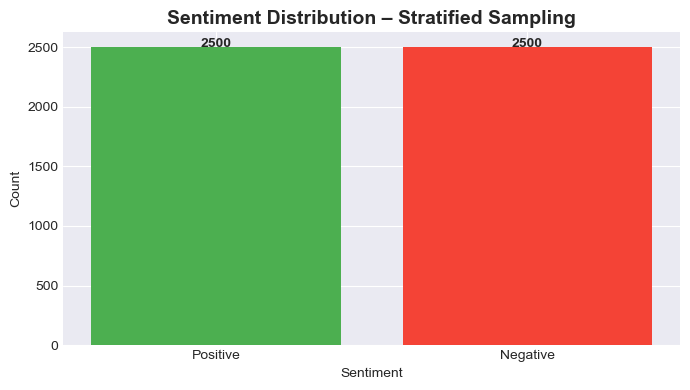

In [6]:
# Select text + rating columns
if 'reviewText' in df.columns:
    df_clean = df[['reviewText', 'overall']].copy()
elif 'summary' in df.columns:
    df_clean = df[['summary', 'overall']].rename(columns={'summary': 'reviewText'}).copy()
else:
    raise ValueError("No text column found in dataset")

df_clean = df_clean.dropna()
df_clean['sentiment'] = df_clean['overall'].apply(
    lambda x: 'Positive' if float(x) >= 4.0 else 'Negative')

print(f"✓ Cleaned dataset : {df_clean.shape}")
print("\nSentiment distribution (should be ~50/50):")
print(df_clean['sentiment'].value_counts())

# Visualise balance
plt.figure(figsize=(7, 4))
counts = df_clean['sentiment'].value_counts()
bars   = plt.bar(counts.index, counts.values, color=['#4CAF50', '#F44336'])
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
             str(int(b.get_height())), ha='center', fontweight='bold')
plt.title('Sentiment Distribution – Stratified Sampling', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

---
## Phase 1 (cont.) – Text Preprocessing
### 1.4 Noise Removal Function

**Fix:** The original regex `[^a-zA-Z0-9\s.,!?'\-]` kept `.  ,  !  ?  '  -` in the text,
so `word_tokenize` produced dirty tokens like `"good,"` and `"game."`.
The fixed version strips **all** punctuation with `[^a-zA-Z0-9\s]`.

In [7]:
def remove_noise(text: str) -> str:
    """
    Remove HTML tags, URLs, e-mails, and ALL punctuation / special characters.
    Only letters, digits, and spaces are preserved.
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>',             ' ', text)   # HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'\S+@\S+',             ' ', text)   # e-mails
    text = re.sub(r'[^a-zA-Z0-9\s]',      ' ', text)   # ALL punctuation ← FIX
    text = re.sub(r'\s+',                 ' ', text).strip()
    return text

# Verification test
_sample = "<b>Great!</b> Cost $49.99... see http://x.com. mail@x.com – 'awesome' game, right?"
print("Original :", _sample)
print("Cleaned  :", remove_noise(_sample))
print("  ↑  All punctuation ($  .  ,  !  '  –) removed correctly")

Original : <b>Great!</b> Cost $49.99... see http://x.com. mail@x.com – 'awesome' game, right?
Cleaned  : Great Cost 49 99 see awesome game right
  ↑  All punctuation ($  .  ,  !  '  –) removed correctly


### 1.5 Stemming vs Lemmatisation Comparison

In [8]:
def compare_stemming_vs_lemmatization(text: str):
    """
    Stemming  – crude suffix chopping (fast, less accurate).
    Lemmatisation – dictionary lookup to find the root word (preferred for NLP).
    """
    stemmer    = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    tokens     = word_tokenize(text.lower())
    return (tokens,
            [stemmer.stem(w) for w in tokens],
            [lemmatizer.lemmatize(w, pos='v') for w in tokens])

_orig, _stem, _lemma = compare_stemming_vs_lemmatization(
    "The batteries were draining quickly and the screens were cracking easily")

print("📊 STEMMING vs LEMMATISATION COMPARISON")
print("=" * 60)
print(pd.DataFrame({'Original': _orig, 'Stemmed': _stem,
                    'Lemmatized': _lemma}).to_string(index=False))
print("\n💡 Lemmatisation gives readable words → better for feature extraction")

📊 STEMMING vs LEMMATISATION COMPARISON
 Original Stemmed Lemmatized
      the     the        the
batteries batteri  batteries
     were    were         be
 draining   drain      drain
  quickly quickli    quickly
      and     and        and
      the     the        the
  screens  screen     screen
     were    were         be
 cracking   crack      crack
   easily  easili     easily

💡 Lemmatisation gives readable words → better for feature extraction


### 1.6 Full Preprocessing Pipeline

In [9]:
def preprocess_text(text: str, remove_stopwords: bool = True) -> str:
    """
    Complete preprocessing pipeline:
      1. remove_noise()         – strips HTML, URLs, ALL punctuation  ← FIXED
      2. Lowercase + tokenise
      3. Keep only alphabetic tokens                                   ← FIXED
      4. Remove stop-words (preserve negations: not, no, never …)
      5. Lemmatise (verb form, then noun form)
    """
    text   = remove_noise(text)
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]   # drop non-alpha tokens ← FIX

    if remove_stopwords:
        sw = set(stopwords.words('english')) - {
            'not','no','never','neither','nobody','none','nothing','nowhere','nor'}
        tokens = [w for w in tokens if w not in sw]

    lem    = WordNetLemmatizer()
    tokens = [lem.lemmatize(w, pos='v') for w in tokens]
    tokens = [lem.lemmatize(w, pos='n') for w in tokens]
    return ' '.join(tokens)

# Verification
_test = """<html>This game is NOT good! The graphics are terrible... $$$
           battery drains too quickly!!! Visit www.example.com for refund.</html>"""
print("Original  :", _test.strip())
print("Processed :", preprocess_text(_test))
print("\n✓ Punctuation removed | 'not' preserved | correctly lemmatised")

Original  : <html>This game is NOT good! The graphics are terrible... $$$
           battery drains too quickly!!! Visit www.example.com for refund.</html>
Processed : game not good graphic terrible battery drain quickly visit refund

✓ Punctuation removed | 'not' preserved | correctly lemmatised


### 1.7 Apply Preprocessing to Entire Dataset

In [10]:
print("Processing all reviews …")
df_clean['processed_text'] = df_clean['reviewText'].apply(preprocess_text)
print("✓ Preprocessing complete!\n")

print("Example transformations:")
print("=" * 80)
for i in range(min(3, len(df_clean))):
    print(f"\nOriginal  {i+1}: {str(df_clean.iloc[i]['reviewText'])[:130]} …")
    print(f"Processed {i+1}: {df_clean.iloc[i]['processed_text'][:130]} …")
    print("-" * 80)

Processing all reviews …
✓ Preprocessing complete!

Example transformations:

Original  1: Very happy with order will by from again …
Processed 1: happy order …
--------------------------------------------------------------------------------

Original  2: Neat! …
Processed 2: neat …
--------------------------------------------------------------------------------

Original  3: meh …
Processed 3: meh …
--------------------------------------------------------------------------------


---
## Phase 2 – Feature Extraction via POS Tagging
### 2.1 Part-of-Speech Tagging

- **Nouns** (NN, NNS, NNP, NNPS) → Product Features (e.g. *battery*, *screen*, *game*)
- **Adjectives** (JJ, JJR, JJS) → Sentiment Descriptors (e.g. *great*, *terrible*, *broken*)

In [11]:
def extract_features_and_sentiments(text: str):
    """Return (nouns, adjectives) from POS-tagged text."""
    tags  = pos_tag(word_tokenize(text.lower()))
    feats = [w for w, p in tags if p in ('NN','NNS','NNP','NNPS')]
    adjs  = [w for w, p in tags if p in ('JJ','JJR','JJS')]
    return feats, adjs

# Demo
_samples = [
    "The battery life is excellent and the screen is crystal clear.",
    "Terrible controls and the graphics are awful.",
    "Amazing gameplay but the sound quality is poor.",
]
print("POS Tagging Examples:")
print("=" * 80)
for rev in _samples:
    f, a = extract_features_and_sentiments(rev)
    print(f"\nReview    : {rev}")
    print(f"Features  : {f}")
    print(f"Sentiments: {a}")
    print("-" * 80)

POS Tagging Examples:

Review    : The battery life is excellent and the screen is crystal clear.
Features  : ['battery', 'life', 'screen']
Sentiments: ['excellent', 'crystal', 'clear']
--------------------------------------------------------------------------------

Review    : Terrible controls and the graphics are awful.
Features  : ['controls', 'graphics']
Sentiments: ['terrible', 'awful']
--------------------------------------------------------------------------------

Review    : Amazing gameplay but the sound quality is poor.
Features  : ['gameplay', 'quality']
Sentiments: ['amazing', 'sound', 'poor']
--------------------------------------------------------------------------------


### 2.2 Extract Features from All Reviews

In [12]:
all_features, all_adjectives = [], []
for text in df_clean['processed_text']:
    f, a = extract_features_and_sentiments(text)
    all_features.extend(f)
    all_adjectives.extend(a)

print(f"✓ Extracted {len(all_features):,} product features")
print(f"✓ Extracted {len(all_adjectives):,} sentiment descriptors")

✓ Extracted 175,030 product features
✓ Extracted 79,827 sentiment descriptors


### 2.3 Top 10 Most Discussed Product Features

📊 TOP 10 MOST DISCUSSED PRODUCT FEATURES
 1. game                 – 18013 mentions
 2. time                 – 3025 mentions
 3. play                 – 2758 mentions
 4. level                – 1813 mentions
 5. character            – 1534 mentions
 6. thing                – 1327 mentions
 7. way                  – 1242 mentions
 8. fun                  – 1239 mentions
 9. mario                – 1088 mentions
10. story                – 1035 mentions


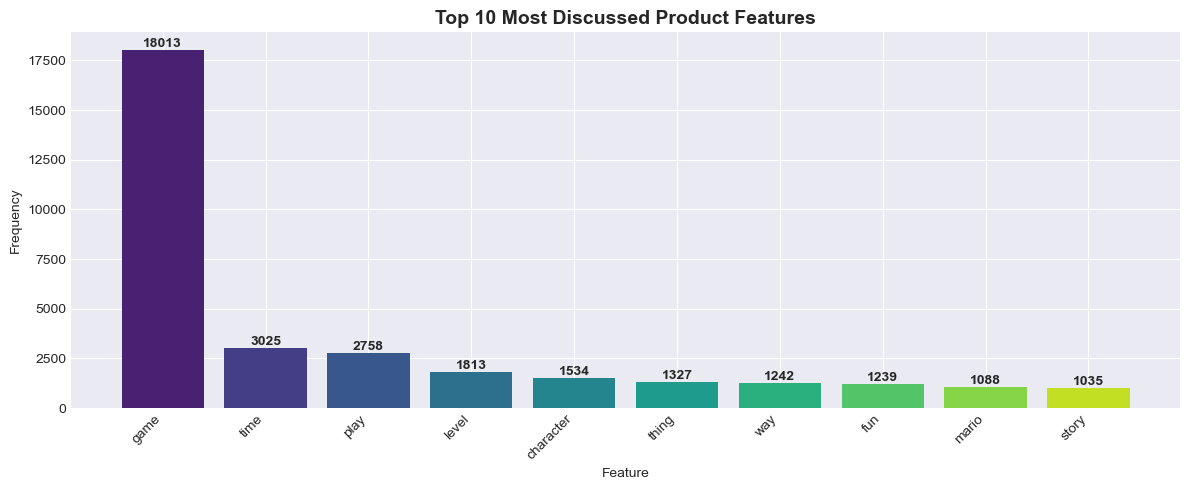

In [13]:
feature_counts  = Counter(all_features)
top_10_features = feature_counts.most_common(10)

print("📊 TOP 10 MOST DISCUSSED PRODUCT FEATURES")
print("=" * 55)
for i, (f, c) in enumerate(top_10_features, 1):
    print(f"{i:2d}. {f:20s} – {c:4d} mentions")

features_df = pd.DataFrame(top_10_features, columns=['Feature', 'Count'])
plt.figure(figsize=(12, 5))
bars = plt.bar(features_df['Feature'], features_df['Count'],
               color=sns.color_palette("viridis", 10))
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h, str(int(h)),
             ha='center', va='bottom', fontweight='bold')
plt.title('Top 10 Most Discussed Product Features', fontsize=14, fontweight='bold')
plt.xlabel('Feature'); plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### 2.4 Top 10 Sentiment Descriptors

📊 TOP 10 MOST COMMON SENTIMENT DESCRIPTORS
 1. good                 – 2247 uses
 2. graphic              – 1832 uses
 3. great                – 1823 uses
 4. many                 – 1070 uses
 5. much                 – 1051 uses
 6. first                –  951 uses
 7. best                 –  941 uses
 8. bad                  –  930 uses
 9. new                  –  913 uses
10. little               –  789 uses


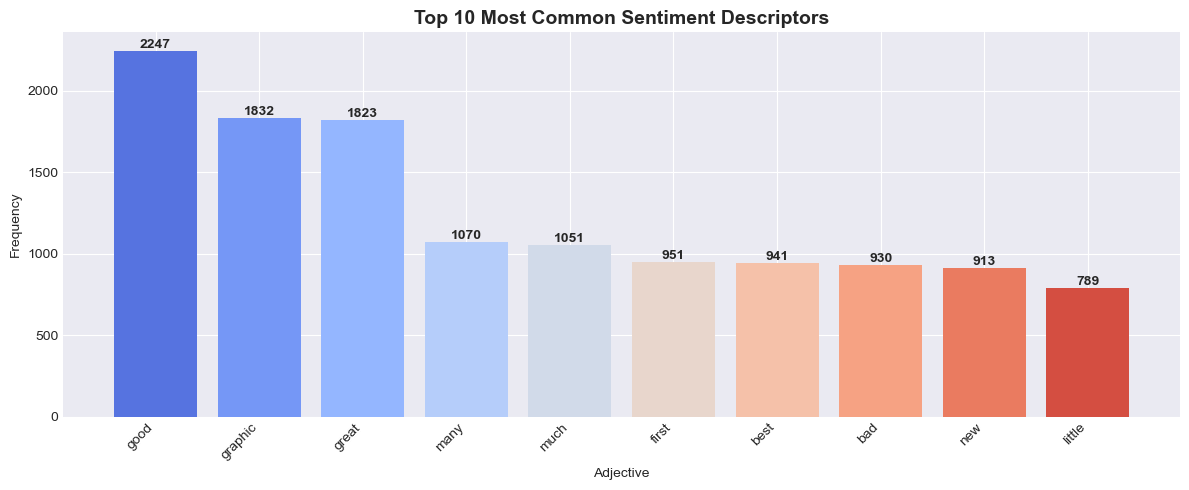

In [14]:
adjective_counts  = Counter(all_adjectives)
top_10_adjectives = adjective_counts.most_common(10)

print("📊 TOP 10 MOST COMMON SENTIMENT DESCRIPTORS")
print("=" * 55)
for i, (a, c) in enumerate(top_10_adjectives, 1):
    print(f"{i:2d}. {a:20s} – {c:4d} uses")

adj_df = pd.DataFrame(top_10_adjectives, columns=['Adjective', 'Count'])
plt.figure(figsize=(12, 5))
bars = plt.bar(adj_df['Adjective'], adj_df['Count'],
               color=sns.color_palette("coolwarm", 10))
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h, str(int(h)),
             ha='center', va='bottom', fontweight='bold')
plt.title('Top 10 Most Common Sentiment Descriptors', fontsize=14, fontweight='bold')
plt.xlabel('Adjective'); plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

---
## Phase 3 – Syntax Analysis: Dependency Parsing
### 3.1 Extract Feature–Sentiment Pairs

spaCy dependency labels used:
- **amod** – adjective directly modifies a noun → *"weak battery"*
- **nsubj** – noun subject with predicate adjective → *"battery is weak"*

In [15]:
def extract_feature_sentiment_pairs(text: str):
    """
    Use spaCy dependency parsing to link product-feature nouns
    to their sentiment adjectives.
    """
    doc = nlp(text)
    pairs = []
    for tok in doc:
        if tok.dep_ == 'amod' and tok.head.pos_ == 'NOUN':
            pairs.append((tok.head.text, tok.text))
        elif tok.pos_ == 'NOUN':
            for ch in tok.head.children:
                if ch.pos_ == 'ADJ' and ch.dep_ in ('acomp', 'attr'):
                    pairs.append((tok.text, ch.text))
    return pairs

# Demo
_demo_sents = [
    "The battery is weak and drains fast.",
    "Amazing graphics but terrible controls.",
    "The game has excellent sound quality and smooth gameplay.",
]
print("🔗 FEATURE-SENTIMENT PAIRS")
print("=" * 70)
for s in _demo_sents:
    print(f"\n  Sentence : {s}")
    for f, a in extract_feature_sentiment_pairs(s):
        print(f"    • {f}  →  {a}")
    print("-" * 70)

🔗 FEATURE-SENTIMENT PAIRS

  Sentence : The battery is weak and drains fast.
    • battery  →  weak
----------------------------------------------------------------------

  Sentence : Amazing graphics but terrible controls.
    • graphics  →  Amazing
    • controls  →  terrible
----------------------------------------------------------------------

  Sentence : The game has excellent sound quality and smooth gameplay.
    • quality  →  excellent
    • quality  →  sound
----------------------------------------------------------------------


### 3.2 Dependency Parse Graph (Visual)

The graph below matches the reference image style:
- Words in **colour-coded rounded boxes** arranged left-to-right
- **Curved Bézier arcs above** the boxes with dependency relation labels
- Fine-grained **POS tags below** each box with downward arrows

| Colour | Meaning |
|--------|---------|
| 🟢 Green | NOUN – Product Feature |
| 🔴 Red | ADJ – Sentiment Word |
| 🔵 Blue | VERB |
| 🟠 Orange | ROOT |
| ⚫ Grey | Other |

In [16]:
def draw_dependency_graph(sentence: str, subtitle: str = ""):
    """
    Draw a horizontal dependency-arc diagram matching the reference image.

    • Words in rounded boxes, evenly spaced left-to-right.
    • Cubic Bézier arcs above boxes, taller for longer dependencies.
    • Dependency relation label at the peak of each arc.
    • Fine-grained POS tags (NN, VBD, JJ …) below each box with a downward arrow.
    """
    doc    = nlp(sentence)
    tokens = list(doc)
    n      = len(tokens)

    POS_COLOR = {
        'NOUN' : '#4CAF50', 'PROPN': '#4CAF50',  # green  – features
        'ADJ'  : '#F44336',                        # red    – sentiment
        'VERB' : '#2196F3', 'AUX'  : '#2196F3',   # blue   – actions
    }
    ROOT_COLOR  = '#FF9800'   # orange
    OTHER_COLOR = '#757575'   # grey

    fig_w   = max(14, n * 1.6)
    fig, ax = plt.subplots(figsize=(fig_w, 5.5))
    ax.set_xlim(-0.7, n - 0.3)
    ax.set_ylim(-1.4, 5.3)
    ax.axis('off')

    BOX_Y, BOX_W, BOX_H = 1.6, 0.88, 0.56

    # ── Draw word boxes ──────────────────────────────────────────────────────
    for i, tok in enumerate(tokens):
        color = ROOT_COLOR if tok.dep_ == 'ROOT' else POS_COLOR.get(tok.pos_, OTHER_COLOR)
        ax.add_patch(mpatches.FancyBboxPatch(
            (i - BOX_W/2, BOX_Y - BOX_H/2), BOX_W, BOX_H,
            boxstyle="round,pad=0.06", linewidth=1.3,
            edgecolor='#333', facecolor=color, alpha=0.88, zorder=3))
        ax.text(i, BOX_Y, tok.text,
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white', zorder=4)
        ax.text(i, BOX_Y - BOX_H/2 - 0.25, tok.tag_,
                ha='center', va='top', fontsize=7.5, color='#333', style='italic')
        ax.annotate("",
            xy=(i, BOX_Y - BOX_H/2 - 0.60), xytext=(i, BOX_Y - BOX_H/2 - 0.38),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.1), zorder=2)

    # ── Draw dependency arcs ─────────────────────────────────────────────────
    ARC_BASE = BOX_Y + BOX_H/2 + 0.18
    max_dist = max((abs(t.i - t.head.i) for t in tokens if t.dep_ != 'ROOT'), default=1)
    SCALE    = (5.3 - ARC_BASE - 0.7) / max_dist

    for tok in tokens:
        if tok.dep_ == 'ROOT':
            ax.text(tok.i, ARC_BASE + max_dist * SCALE + 0.30, 'ROOT',
                    ha='center', va='bottom', fontsize=8.5,
                    color=ROOT_COLOR, fontweight='bold')
            ax.annotate("",
                xy=(tok.i, ARC_BASE + max_dist * SCALE + 0.28),
                xytext=(tok.i, ARC_BASE + 0.05),
                arrowprops=dict(arrowstyle='-', color=ROOT_COLOR, lw=1.2))
            continue

        src, dst = tok.head.i, tok.i
        dist     = abs(src - dst)
        peak     = ARC_BASE + dist * SCALE
        mid      = (src + dst) / 2.0

        verts = [(src, ARC_BASE),
                 (src + (dst-src)*0.25, peak),
                 (src + (dst-src)*0.75, peak),
                 (dst, ARC_BASE)]
        codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
        ax.add_patch(mpatches.PathPatch(
            Path(verts, codes), facecolor='none', edgecolor='#2E7D32', lw=1.5, zorder=2))

        direction = 1 if src > dst else -1
        ax.annotate("",
            xy=(dst, ARC_BASE + 0.02),
            xytext=(dst + direction * 0.18, ARC_BASE + 0.22),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.3), zorder=5)

        ax.text(mid, peak + 0.09, tok.dep_,
                ha='center', va='bottom', fontsize=7.5,
                color='#1B5E20', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.65, pad=1.2, linewidth=0))

    # ── Legend ───────────────────────────────────────────────────────────────
    ax.legend(handles=[
        mpatches.Patch(color='#4CAF50', label='NOUN  – Product Feature'),
        mpatches.Patch(color='#F44336', label='ADJ   – Sentiment'),
        mpatches.Patch(color='#2196F3', label='VERB'),
        mpatches.Patch(color='#FF9800', label='ROOT'),
        mpatches.Patch(color='#757575', label='Other'),
    ], loc='lower left', fontsize=8, framealpha=0.9)

    ttl = f"Dependency Parse Graph{' – ' + subtitle if subtitle else ''}"
    ax.set_title(f"{ttl}\n\"{sentence}\"", fontsize=10, fontweight='bold', pad=6)
    plt.tight_layout(); plt.show(); print()

print("✓ draw_dependency_graph() defined")

✓ draw_dependency_graph() defined


### 3.3 Visualise Dependency Graphs

🌳 DEPENDENCY PARSE GRAPH VISUALISATIONS

── Sentence 1 – Product Review
Token           | POS    | DEP        | HEAD
--------------------------------------------------
The             | DET    | det        | life
battery         | NOUN   | compound   | life
life            | NOUN   | nsubj      | is
is              | AUX    | ROOT       | is
excellent       | ADJ    | acomp      | is
but             | CCONJ  | cc         | is
the             | DET    | det        | quality
screen          | NOUN   | compound   | quality
quality         | NOUN   | nsubj      | is
is              | AUX    | conj       | is
poor            | ADJ    | acomp      | is
.               | PUNCT  | punct      | is
Feature–Sentiment pairs: [('life', 'excellent'), ('quality', 'poor')]


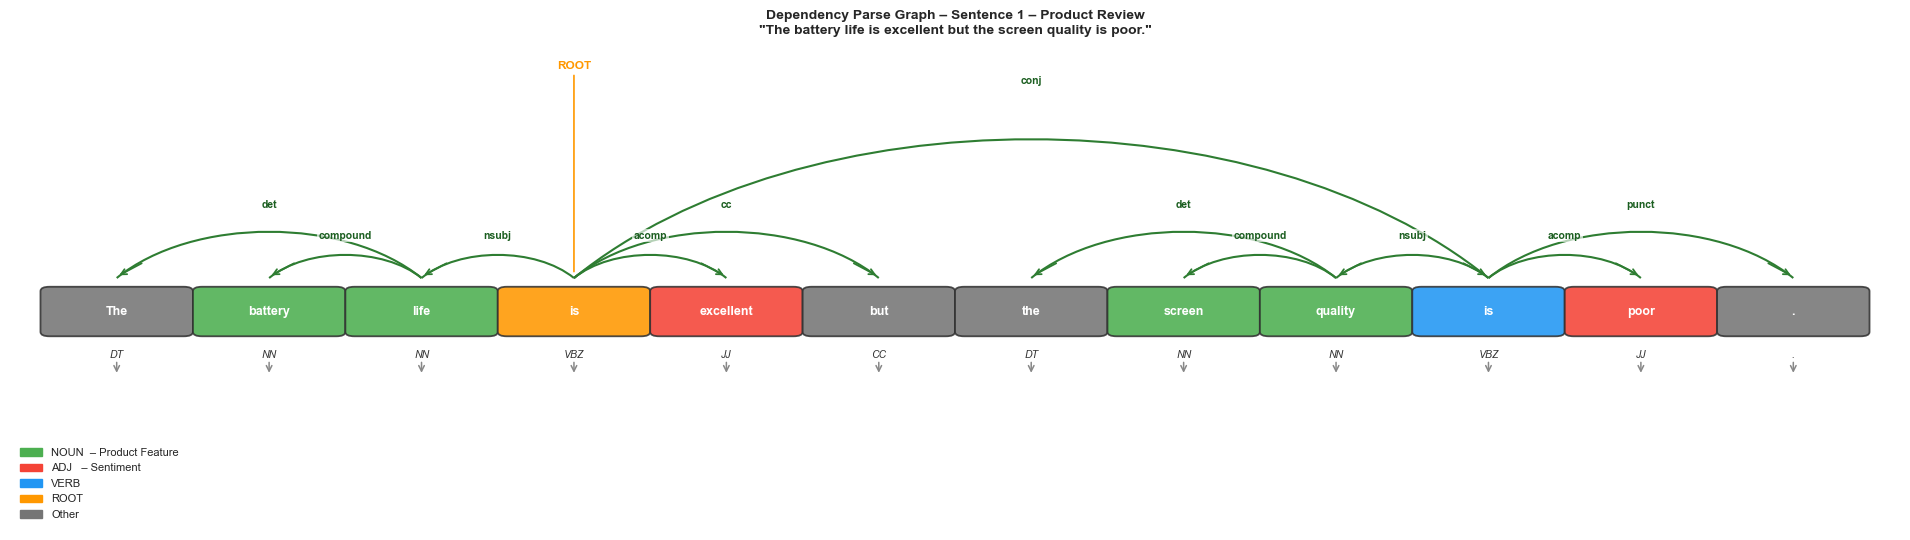



── Sentence 2 – Product Review
Token           | POS    | DEP        | HEAD
--------------------------------------------------
I               | PRON   | nsubj      | love
love            | VERB   | ROOT       | love
the             | DET    | det        | graphics
amazing         | ADJ    | amod       | graphics
graphics        | NOUN   | dobj       | love
but             | CCONJ  | cc         | love
the             | DET    | det        | controls
terrible        | ADJ    | amod       | controls
controls        | NOUN   | nsubj      | ruin
ruin            | VERB   | conj       | love
it              | PRON   | dobj       | ruin
.               | PUNCT  | punct      | ruin
Feature–Sentiment pairs: [('graphics', 'amazing'), ('controls', 'terrible')]


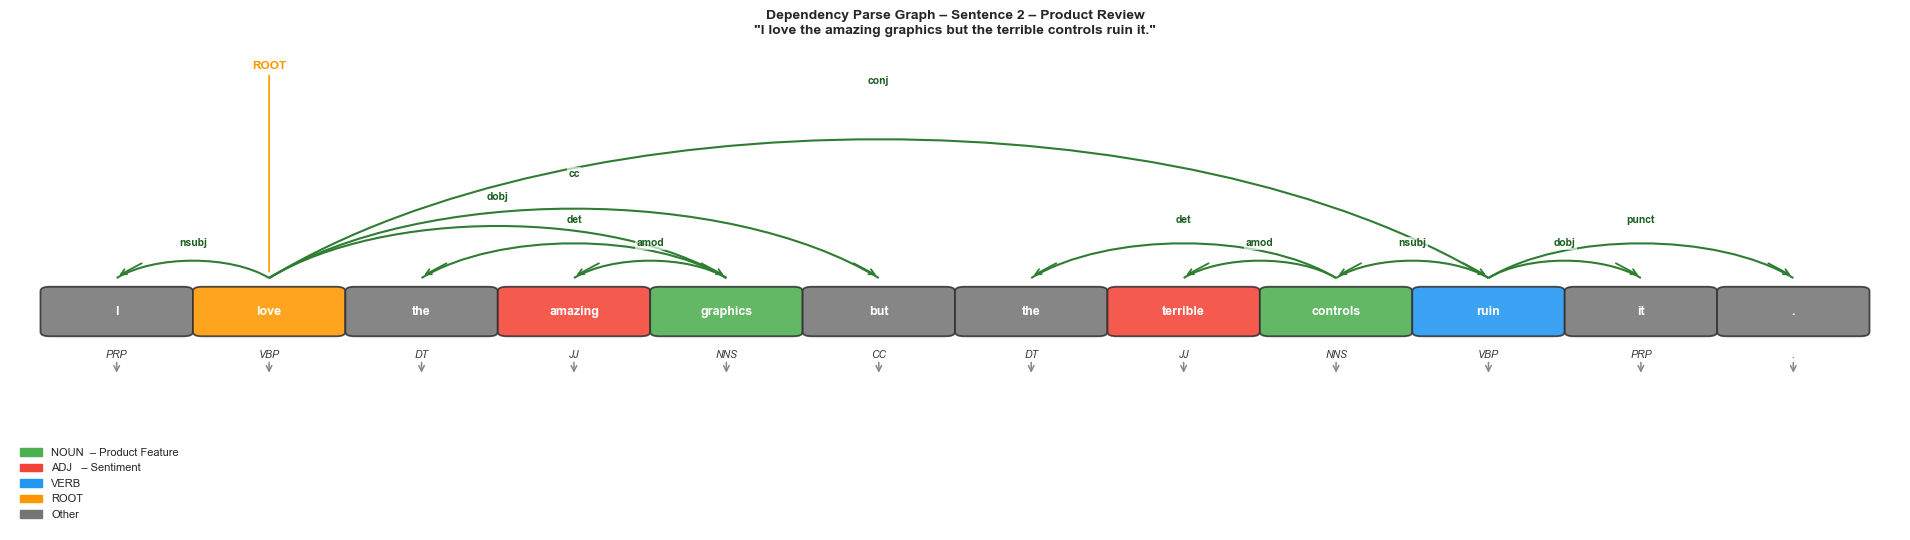



── Classic Reference Example
Token           | POS    | DEP        | HEAD
--------------------------------------------------
I               | PRON   | nsubj      | saw
saw             | VERB   | ROOT       | saw
the             | DET    | det        | ship
ship            | NOUN   | dobj       | saw
with            | ADP    | prep       | saw
very            | ADV    | advmod     | strong
strong          | ADJ    | amod       | binoculars
binoculars      | NOUN   | pobj       | with
.               | PUNCT  | punct      | saw
Feature–Sentiment pairs: [('binoculars', 'strong')]


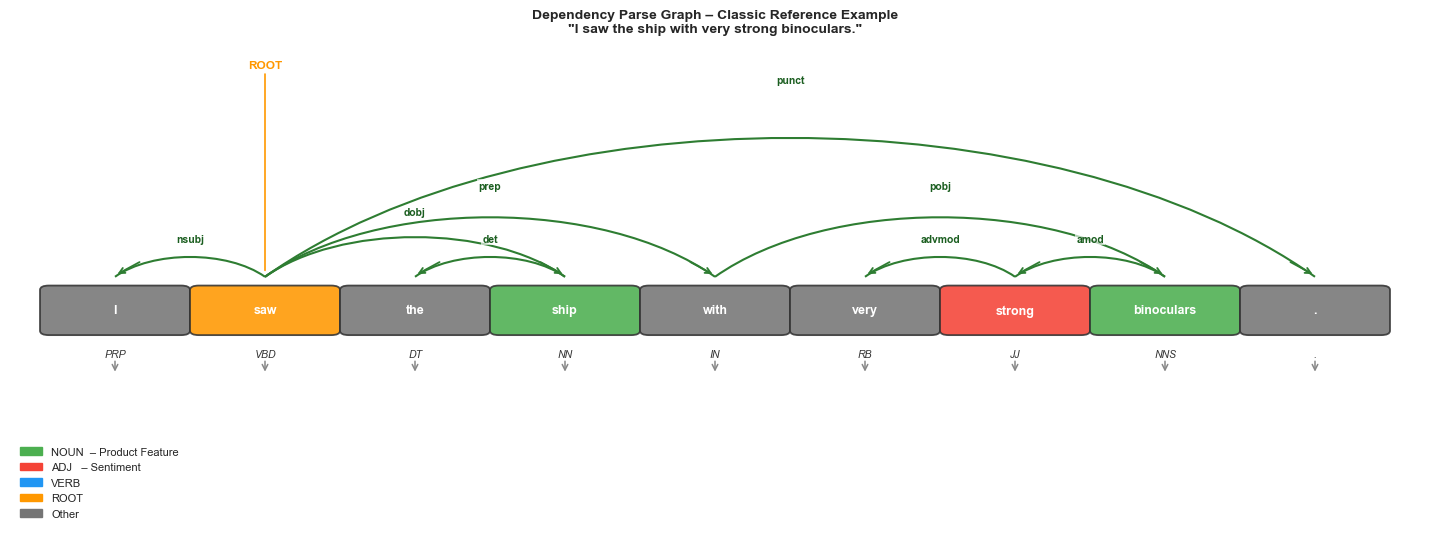

In [17]:
_vis_sentences = [
    ("The battery life is excellent but the screen quality is poor.",   "Sentence 1 – Product Review"),
    ("I love the amazing graphics but the terrible controls ruin it.",  "Sentence 2 – Product Review"),
    ("I saw the ship with very strong binoculars.",                     "Classic Reference Example"),
]

print("🌳 DEPENDENCY PARSE GRAPH VISUALISATIONS")
print("=" * 80)

for sentence, label in _vis_sentences:
    doc = nlp(sentence)
    print(f"\n── {label}")
    print(f"{'Token':15s} | {'POS':6s} | {'DEP':10s} | HEAD")
    print("-" * 50)
    for tok in doc:
        print(f"{tok.text:15s} | {tok.pos_:6s} | {tok.dep_:10s} | {tok.head.text}")
    print(f"Feature–Sentiment pairs: {extract_feature_sentiment_pairs(sentence)}")
    print("=" * 80)
    draw_dependency_graph(sentence, label)

### 3.4 Top Feature–Sentiment Pairs Across Dataset

In [18]:
print("Extracting feature-sentiment pairs from dataset …")
all_pairs = []
for text in df_clean['reviewText'].head(1000):
    all_pairs.extend(extract_feature_sentiment_pairs(text))

pair_counts = Counter(all_pairs)
top_pairs   = pair_counts.most_common(15)
print(f"✓ Extracted {len(all_pairs):,} pairs")

print("\nTOP 15 FEATURE-SENTIMENT COMBINATIONS")
print("=" * 60)
for i, ((f, a), c) in enumerate(top_pairs, 1):
    print(f"{i:2d}. {f:15s} + {a:15s}  ({c}×)")

Extracting feature-sentiment pairs from dataset …
✓ Extracted 8,926 pairs

TOP 15 FEATURE-SENTIMENT COMBINATIONS
 1. game            + good             (64×)
 2. game            + great            (50×)
 3. game            + first            (43×)
 4. games           + other            (41×)
 5. game            + best             (35×)
 6. game            + fun              (34×)
 7. games           + best             (33×)
 8. time            + first            (28×)
 9. graphics        + good             (25×)
10. game            + better           (21×)
11. thing           + only             (20×)
12. time            + long             (17×)
13. person          + first            (17×)
14. games           + first            (16×)
15. game            + other            (16×)


---
## Phase 4 – Sentiment Classification with Machine Learning
### 4.1 TF-IDF Vectorisation

In [19]:
X = df_clean['processed_text']
y = df_clean['sentiment']

print("Building TF-IDF matrix …")
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams (captures "not good")
    min_df=2,
    max_df=0.95,
)
X_tfidf = vectorizer.fit_transform(X)
print(f"✓ Matrix: {X_tfidf.shape[0]:,} reviews × {X_tfidf.shape[1]:,} features")
print(f"Sample features: {list(vectorizer.get_feature_names_out()[:20])}")

Building TF-IDF matrix …
✓ Matrix: 5,000 reviews × 5,000 features
Sample features: ['ability', 'able', 'able get', 'able play', 'able use', 'absolute', 'absolutely', 'absolutely love', 'absolutely no', 'accept', 'acceptable', 'access', 'accident', 'accidentally', 'acclaim', 'accompany', 'accomplish', 'accord', 'account', 'accurate']


### 4.2 Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y,          # keeps 50/50 balance in both splits
)
print(f"Training set : {X_train.shape[0]:,} reviews")
print(f"Testing set  : {X_test.shape[0]:,} reviews")
print("\nTraining distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting distribution:")
print(pd.Series(y_test).value_counts())

Training set : 4,000 reviews
Testing set  : 1,000 reviews

Training distribution:
sentiment
Positive    2000
Negative    2000
Name: count, dtype: int64

Testing distribution:
sentiment
Negative    500
Positive    500
Name: count, dtype: int64


### 4.3 Train Logistic Regression Model

In [21]:
print("Training Logistic Regression …")
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("✓ Training complete!")

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

Training Logistic Regression …
✓ Training complete!


### 4.4 Model Evaluation

In [22]:
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, pos_label='Positive')

print("=" * 55)
print("📊 MODEL PERFORMANCE")
print("=" * 55)
print(f"Accuracy : {accuracy:.2%}")
print(f"F1-Score : {f1:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

📊 MODEL PERFORMANCE
Accuracy : 84.20%
F1-Score : 83.98%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.86      0.84       500
    Positive       0.85      0.83      0.84       500

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



### 4.5 Confusion Matrix

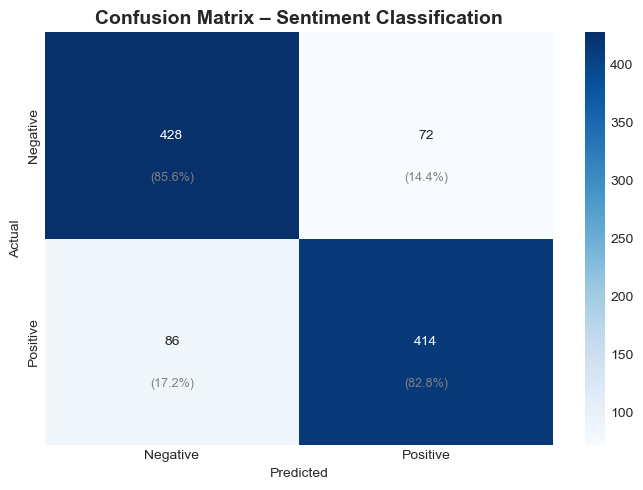

False Positives (Negative→Positive): 72
False Negatives (Positive→Negative): 86


In [23]:
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Positive'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.72, f"({cm[i,j]/cm[i].sum()*100:.1f}%)",
                 ha='center', fontsize=9, color='gray')
plt.title('Confusion Matrix – Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

fp = cm[0, 1]; fn = cm[1, 0]
print(f"False Positives (Negative→Positive): {fp}")
print(f"False Negatives (Positive→Negative): {fn}")

### 4.6 Feature Importance

In [24]:
feat_names = vectorizer.get_feature_names_out()
coefs      = model.coef_[0]
fi = pd.DataFrame({'feature': feat_names, 'coefficient': coefs}).sort_values(
    'coefficient', ascending=False)

print("TOP 15 POSITIVE SENTIMENT INDICATORS")
print("=" * 55)
for i, row in enumerate(fi.head(15).itertuples(), 1):
    print(f"{i:2d}. {row.feature:28s} ({row.coefficient:+.4f})")

print("\nTOP 15 NEGATIVE SENTIMENT INDICATORS")
print("=" * 55)
for i, row in enumerate(fi.tail(15).itertuples(), 1):
    print(f"{i:2d}. {row.feature:28s} ({row.coefficient:+.4f})")

TOP 15 POSITIVE SENTIMENT INDICATORS
 1. best                         (+3.1779)
 2. love                         (+3.0688)
 3. awesome                      (+2.8644)
 4. great                        (+2.8018)
 5. perfect                      (+2.7338)
 6. amaze                        (+2.4424)
 7. classic                      (+2.1090)
 8. zelda                        (+2.0335)
 9. work great                   (+1.9674)
10. mario                        (+1.7110)
11. crash                        (+1.6483)
12. thank                        (+1.6380)
13. love game                    (+1.5760)
14. still                        (+1.5709)
15. gem                          (+1.5029)

TOP 15 NEGATIVE SENTIMENT INDICATORS
 1. terrible                     (-1.5814)
 2. return                       (-1.6118)
 3. dreamcast                    (-1.6341)
 4. snes                         (-1.6373)
 5. decent                       (-1.6801)
 6. suck                         (-1.7433)
 7. however           

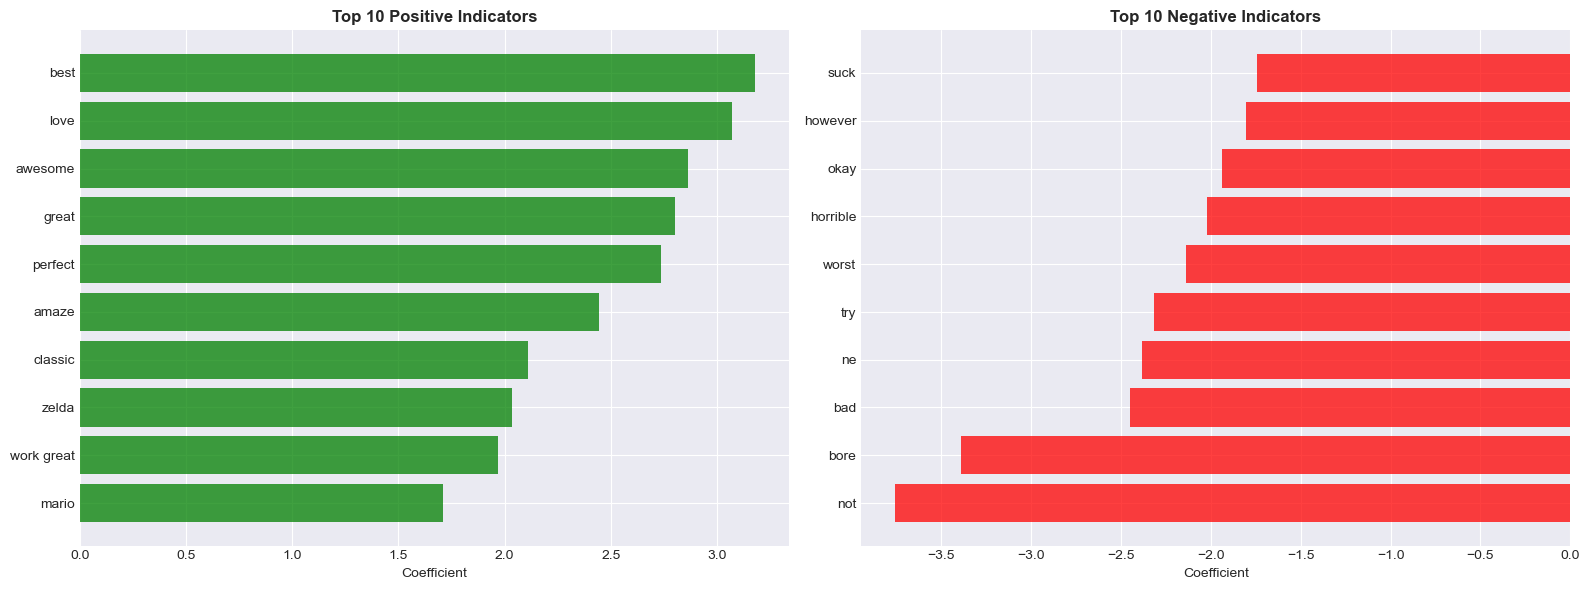

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

tp = fi.head(10)
ax1.barh(range(10), tp['coefficient'], color='green', alpha=0.75)
ax1.set_yticks(range(10)); ax1.set_yticklabels(tp['feature'])
ax1.set_xlabel('Coefficient'); ax1.set_title('Top 10 Positive Indicators', fontweight='bold')
ax1.invert_yaxis()

tn = fi.tail(10)
ax2.barh(range(10), tn['coefficient'], color='red', alpha=0.75)
ax2.set_yticks(range(10)); ax2.set_yticklabels(tn['feature'])
ax2.set_xlabel('Coefficient'); ax2.set_title('Top 10 Negative Indicators', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout(); plt.show()

---
## Business Insights for Product Managers
### 5.1 Sentiment Analysis by Product Feature

In [26]:
def analyze_feature_sentiment(kw, df, model, vec):
    """Sentiment breakdown for reviews mentioning a specific product feature."""
    mask = df['processed_text'].str.contains(kw, case=False, na=False)
    sub  = df[mask].copy()
    if sub.empty: return None
    preds = model.predict(vec.transform(sub['processed_text']))
    dist  = pd.Series(preds).value_counts(normalize=True) * 100
    return {'feature': kw, 'total_mentions': len(sub),
            'positive_pct': dist.get('Positive', 0),
            'negative_pct': dist.get('Negative', 0)}

kws              = ['game','graphic','control','sound','story',
                    'gameplay','multiplayer','character','level','price']
feature_analysis = [r for k in kws
                    if (r := analyze_feature_sentiment(k, df_clean, model, vectorizer))]
feature_summary  = pd.DataFrame(feature_analysis).sort_values('negative_pct', ascending=False)

print("PRODUCT FEATURE SENTIMENT ANALYSIS")
print("=" * 75)
for _, row in feature_summary.iterrows():
    print(f"{row['feature'].upper():15s} | Mentions: {row['total_mentions']:4.0f} | "
          f"Pos: {row['positive_pct']:5.1f}% | Neg: {row['negative_pct']:5.1f}%")

PRODUCT FEATURE SENTIMENT ANALYSIS
SOUND           | Mentions:  583 | Pos:  32.2% | Neg:  67.8%
GRAPHIC         | Mentions: 1428 | Pos:  34.7% | Neg:  65.3%
GAMEPLAY        | Mentions:  636 | Pos:  34.7% | Neg:  65.3%
CONTROL         | Mentions:  863 | Pos:  35.0% | Neg:  65.0%
STORY           | Mentions:  751 | Pos:  35.3% | Neg:  64.7%
CHARACTER       | Mentions:  810 | Pos:  35.4% | Neg:  64.6%
LEVEL           | Mentions:  848 | Pos:  36.6% | Neg:  63.4%
PRICE           | Mentions:  216 | Pos:  42.6% | Neg:  57.4%
GAME            | Mentions: 3907 | Pos:  44.3% | Neg:  55.7%
MULTIPLAYER     | Mentions:  171 | Pos:  53.2% | Neg:  46.8%


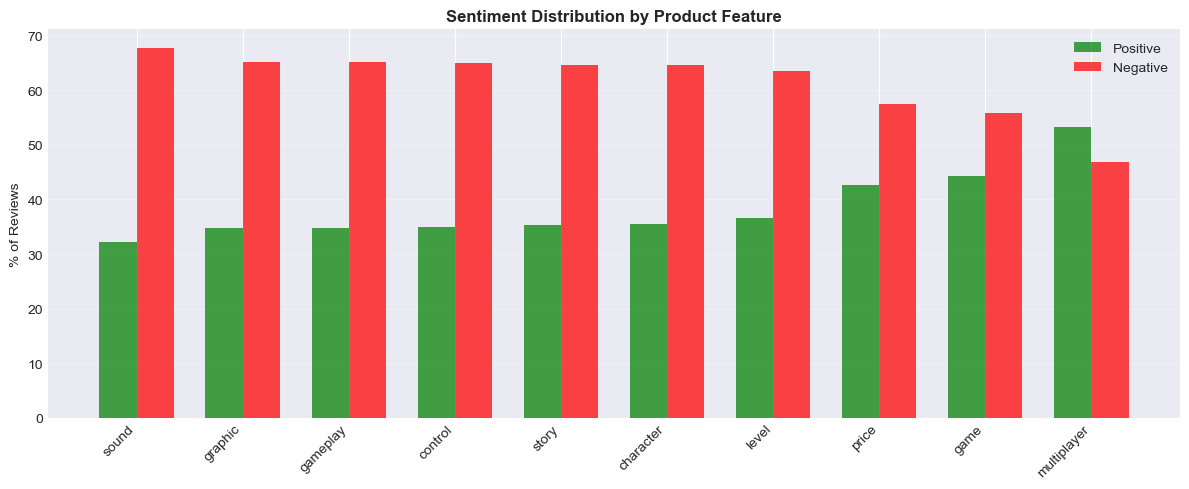

In [27]:
if not feature_summary.empty:
    x = np.arange(len(feature_summary)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, feature_summary['positive_pct'], w, label='Positive', color='green', alpha=0.72)
    ax.bar(x + w/2, feature_summary['negative_pct'], w, label='Negative', color='red',   alpha=0.72)
    ax.set_xticks(x); ax.set_xticklabels(feature_summary['feature'], rotation=45, ha='right')
    ax.set_ylabel('% of Reviews')
    ax.set_title('Sentiment Distribution by Product Feature', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

### 5.2 Top Features in Negative Reviews

In [28]:
neg_rev            = df_clean[df_clean['sentiment'] == 'Negative']
neg_feat, neg_pairs = [], []
for text in neg_rev['reviewText']:
    f, _ = extract_features_and_sentiments(text); neg_feat.extend(f)
    neg_pairs.extend(extract_feature_sentiment_pairs(text))

neg_fc = Counter(neg_feat)
top_nf = neg_fc.most_common(10)

print("TOP 10 FEATURES IN NEGATIVE REVIEWS")
print("=" * 65)
for i, (f, c) in enumerate(top_nf, 1):
    print(f"{i:2d}. {f:20s} – {c:4d} mentions")

TOP 10 FEATURES IN NEGATIVE REVIEWS
 1. game                 – 8789 mentions
 2. i                    – 5094 mentions
 3. games                – 1676 mentions
 4. time                 – 1295 mentions
 5. graphics             – 1159 mentions
 6. way                  –  760 mentions
 7. characters           –  622 mentions
 8. level                –  610 mentions
 9. fun                  –  599 mentions
10. story                –  589 mentions


In [30]:
print("\nTOP 3 NEGATIVE FEATURES + COMMON COMPLAINTS")
print("=" * 65)
for feat, _ in top_nf[:3]:
    adjs = Counter(a for f, a in neg_pairs if f == feat).most_common(5)
    print(f"\n  {feat.upper()}  ({neg_fc[feat]} mentions)")
    for adj, c in adjs:
        print(f"    • {adj}  ({c}×)")
    print("-" * 65)


TOP 3 NEGATIVE FEATURES + COMMON COMPLAINTS

  GAME  (8789 mentions)
    • good  (183×)
    • great  (137×)
    • fun  (132×)
    • first  (110×)
    • bad  (85×)
-----------------------------------------------------------------

  I  (5094 mentions)
-----------------------------------------------------------------

  GAMES  (1676 mentions)
    • other  (125×)
    • many  (49×)
    • better  (41×)
    • first  (34×)
    • most  (30×)
-----------------------------------------------------------------


### 5.3 Sample Predictions on New Reviews

In [31]:
def predict_sentiment(text):
    """Predict sentiment of a new review with confidence score."""
    p    = preprocess_text(text)
    X_n  = vectorizer.transform([p])
    pred = model.predict(X_n)[0]
    conf = max(model.predict_proba(X_n)[0]) * 100
    return pred, conf

test_reviews = [
    "This game is absolutely fantastic! The graphics are stunning.",
    "Terrible waste of money. The game crashes constantly.",
    "Pretty good game overall, but the loading times are way too long.",
    "Not worth the price. Very disappointed with the quality.",
    "Best game I've played this year! Highly recommend!",
]

print("SAMPLE PREDICTIONS")
print("=" * 80)
for i, rev in enumerate(test_reviews, 1):
    pred, conf = predict_sentiment(rev)
    emoji = "✅" if pred == 'Positive' else "❌"
    print(f"\nReview {i}: {rev}")
    print(f"  {emoji} {pred}  (confidence: {conf:.1f}%)")
    print("-" * 80)

SAMPLE PREDICTIONS

Review 1: This game is absolutely fantastic! The graphics are stunning.
  ✅ Positive  (confidence: 62.4%)
--------------------------------------------------------------------------------

Review 2: Terrible waste of money. The game crashes constantly.
  ❌ Negative  (confidence: 75.5%)
--------------------------------------------------------------------------------

Review 3: Pretty good game overall, but the loading times are way too long.
  ❌ Negative  (confidence: 54.8%)
--------------------------------------------------------------------------------

Review 4: Not worth the price. Very disappointed with the quality.
  ❌ Negative  (confidence: 72.6%)
--------------------------------------------------------------------------------

Review 5: Best game I've played this year! Highly recommend!
  ✅ Positive  (confidence: 91.0%)
--------------------------------------------------------------------------------


---
## Final Executive Summary

In [32]:
tot = len(df_clean)
pc  = (df_clean['sentiment'] == 'Positive').sum()
nc  = (df_clean['sentiment'] == 'Negative').sum()

print("=" * 75)
print("📊 EXECUTIVE SUMMARY – VIDEO GAMES PRODUCT CATEGORY")
print("=" * 75)

print(f"\n1. OVERALL SENTIMENT")
print(f"   Total reviews   : {tot:,}")
print(f"   Positive        : {pc:,} ({pc/tot*100:.1f}%)")
print(f"   Negative        : {nc:,} ({nc/tot*100:.1f}%)")
print(f"   Balance         : {'✓ Balanced (stratified sampling)' if abs(pc/tot*100-50)<5 else '⚠ Imbalanced'}")

print(f"\n2. TOP 3 PROBLEM AREAS")
for i, (feat, cnt) in enumerate(top_nf[:3], 1):
    adj_str = ', '.join(f"'{a}'" for a, _ in Counter(
        [aj for f, aj in neg_pairs if f == feat]).most_common(3))
    print(f"   {i}. {feat.upper()} ({cnt} mentions) – described as {adj_str}")

print(f"\n3. MODEL PERFORMANCE")
print(f"   Accuracy  : {accuracy:.1%}")
print(f"   F1-Score  : {f1:.1%}")

print(f"\n4. KEY RECOMMENDATIONS")
print(f"   • Focus on  : {', '.join(f for f, _ in top_nf[:3])}")
print(f"   • Auto-route negative reviews to support team")
print(f"   • Track feature-level sentiment trends over time")
print(f"\n{'='*75}")
print("✓ Analysis complete!")
print("=" * 75)

📊 EXECUTIVE SUMMARY – VIDEO GAMES PRODUCT CATEGORY

1. OVERALL SENTIMENT
   Total reviews   : 5,000
   Positive        : 2,500 (50.0%)
   Negative        : 2,500 (50.0%)
   Balance         : ✓ Balanced (stratified sampling)

2. TOP 3 PROBLEM AREAS
   1. GAME (8789 mentions) – described as 'good', 'great', 'fun'
   2. I (5094 mentions) – described as 
   3. GAMES (1676 mentions) – described as 'other', 'many', 'better'

3. MODEL PERFORMANCE
   Accuracy  : 84.2%
   F1-Score  : 84.0%

4. KEY RECOMMENDATIONS
   • Focus on  : game, i, games
   • Auto-route negative reviews to support team
   • Track feature-level sentiment trends over time

✓ Analysis complete!


## Save Model & Vectoriser

In [33]:
with open('sentiment_model.pkl', 'wb') as fh:
    pickle.dump(model, fh)
with open('tfidf_vectorizer.pkl', 'wb') as fh:
    pickle.dump(vectorizer, fh)

print("✓ Saved: sentiment_model.pkl")
print("✓ Saved: tfidf_vectorizer.pkl")
print("\nTo reload later:")
print("  model      = pickle.load(open('sentiment_model.pkl', 'rb'))")
print("  vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))")

✓ Saved: sentiment_model.pkl
✓ Saved: tfidf_vectorizer.pkl

To reload later:
  model      = pickle.load(open('sentiment_model.pkl', 'rb'))
  vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
